# 📊 Notebook 2 — Exploratory Data Analysis (EDA)
**Project:** FAANG Stock Price Forecasting
**Goal:** Visually explore the data — trends, growth, risk, and relationships between stocks.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ Libraries ready')

✅ Libraries ready


## Step 2 — Load Data

In [2]:
close_df = pd.read_csv("data/FAANG_close_prices.csv", index_col="Date", parse_dates=True)

TICKERS = ["META", "AAPL", "AMZN", "NFLX", "GOOGL"]
colors  = ["#007AFF", "#34C759", "#FF9500", "#FF3B30", "#AF52DE"]

print(f"Shape : {close_df.shape}")
print(f"Dates : {close_df.index.min().date()} → {close_df.index.max().date()}")
close_df.head()

Shape : (1509, 5)
Dates : 2019-01-02 → 2024-12-30


,META,AAPL,AMZN,NFLX,GOOGL
Date,,,,,
2019-01-02,134.498871,37.469204,76.956497,26.766001,52.270504
2019-01-03,130.593170,33.737000,75.014000,27.120001,50.822845
2019-01-04,136.749130,35.177200,78.769501,29.757000,53.429729
2019-01-07,136.848282,35.098900,81.475502,31.534000,53.323174
2019-01-08,141.289261,35.767998,82.829002,32.027000,53.791523


## Step 3 — Closing Price of Each Stock (5 Year Trend)

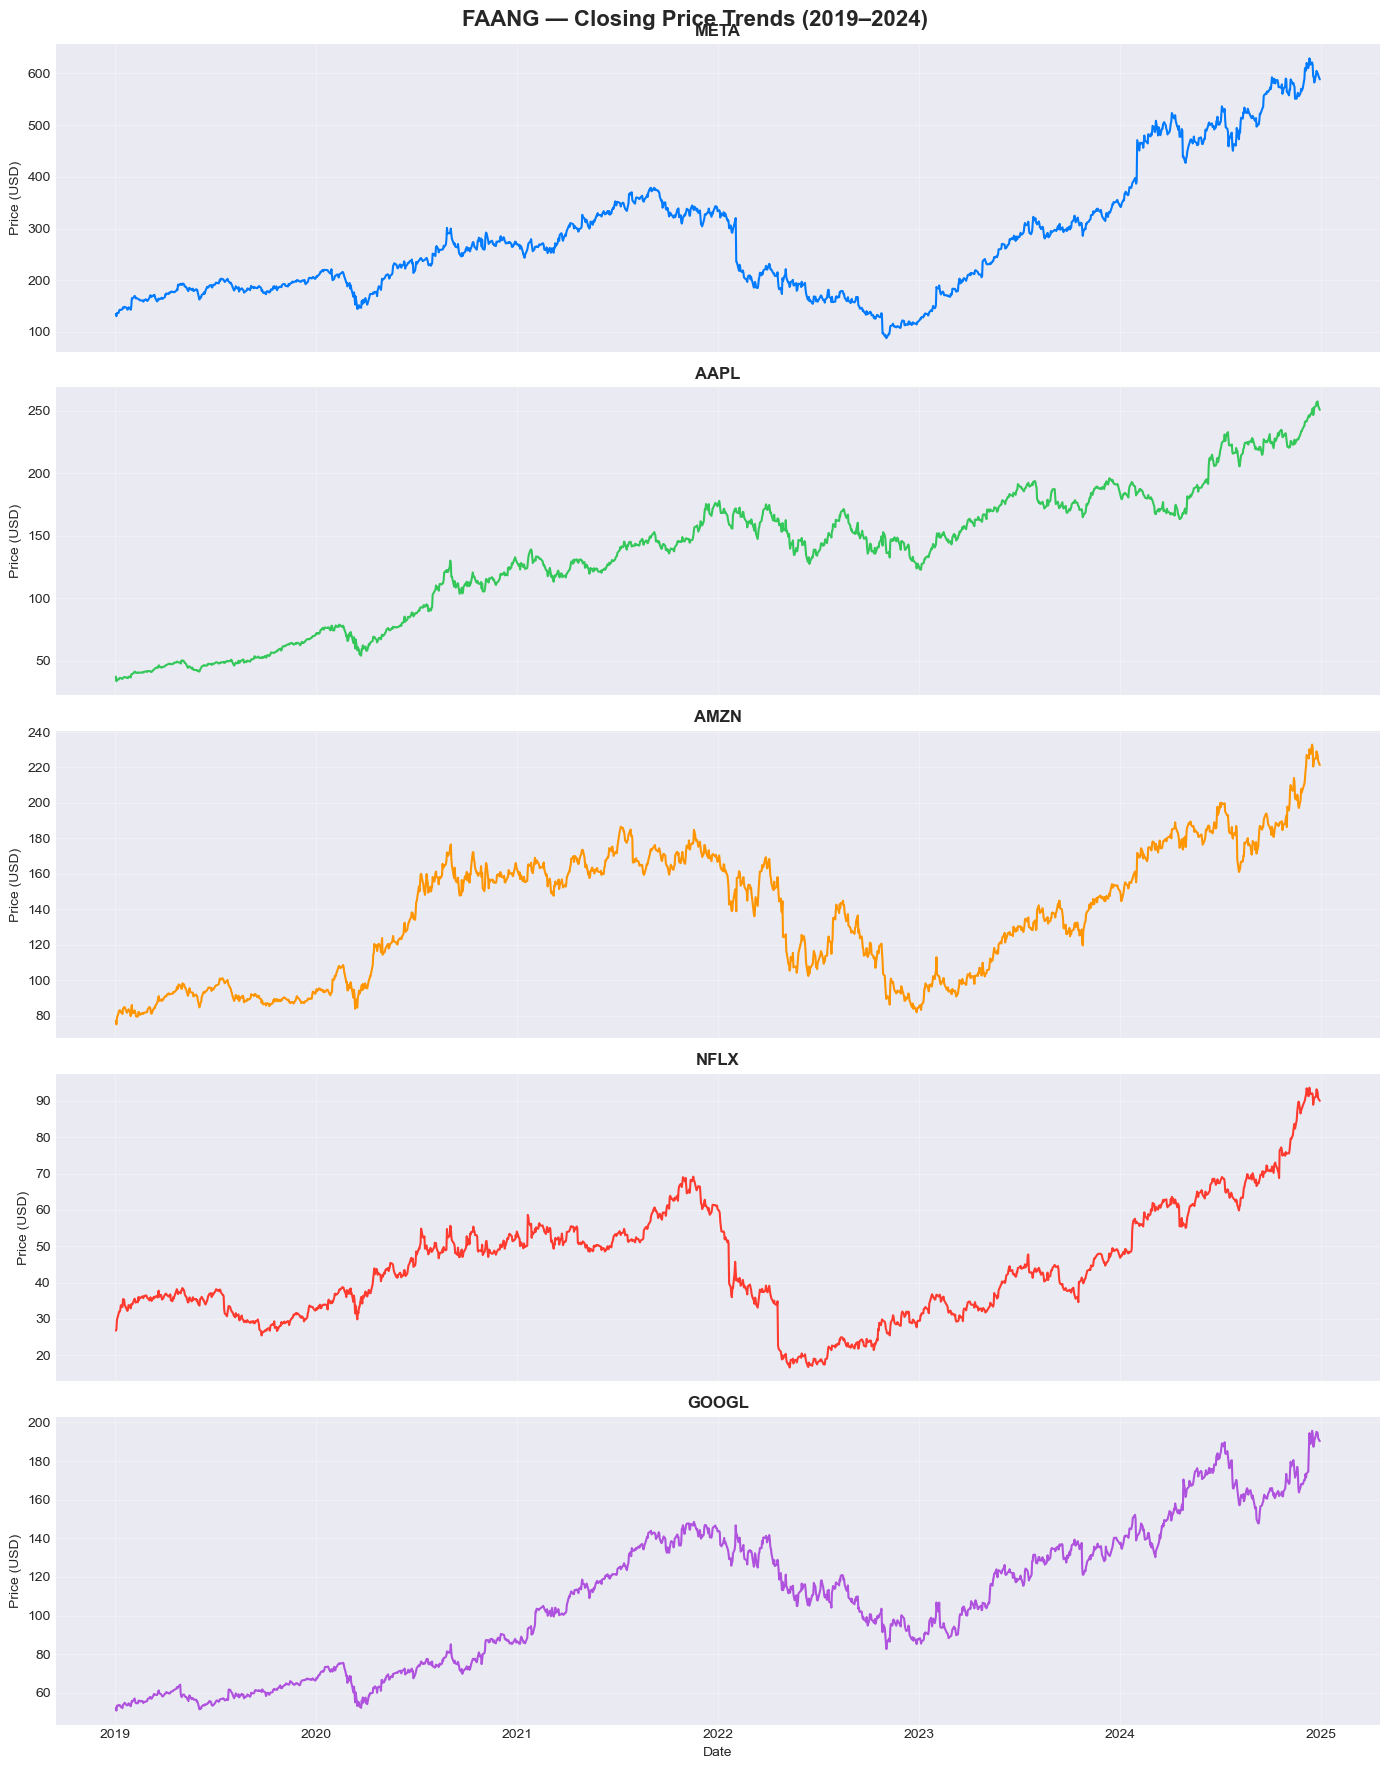

✅ Chart saved


In [3]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
fig.suptitle("FAANG — Closing Price Trends (2019–2024)", fontsize=16, fontweight="bold")

for i, (ticker, color) in enumerate(zip(TICKERS, colors)):
    axes[i].plot(close_df.index, close_df[ticker], color=color, linewidth=1.5)
    axes[i].set_title(ticker, fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Price (USD)")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("data/01_closing_prices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

## Step 4 — Normalized Price Chart (Who Grew the Most?)

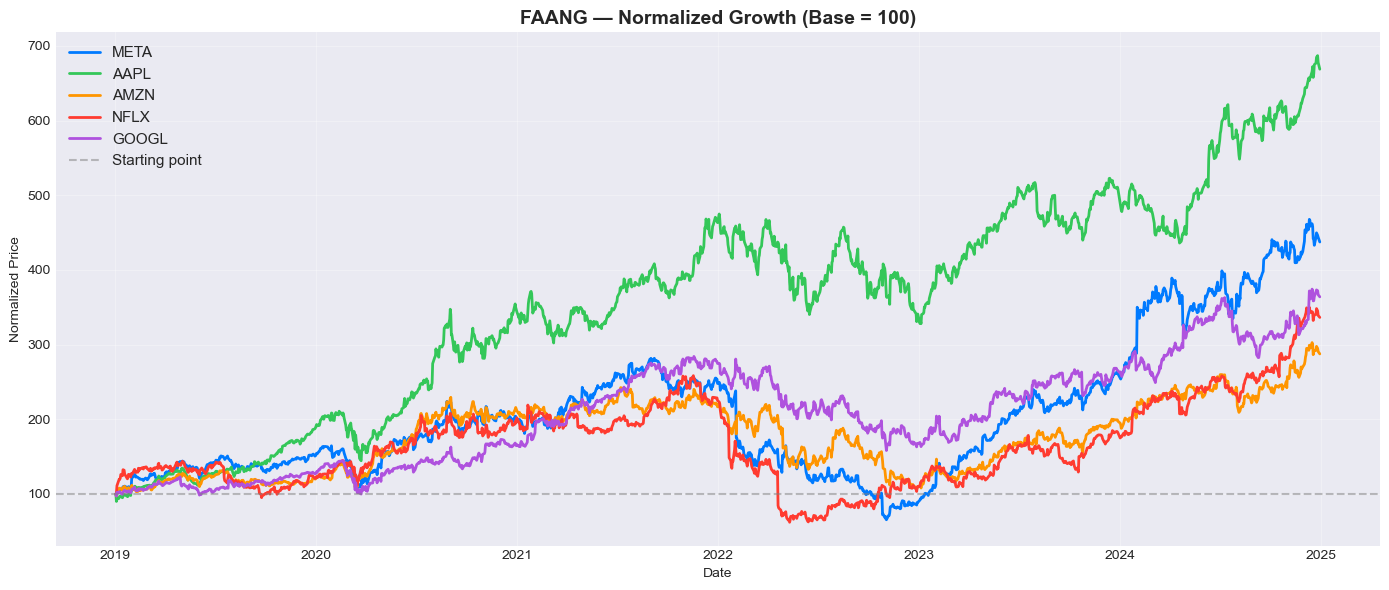

Total Growth (2019 → 2024):
  META : +337.4%
  AAPL : +568.8%
  AMZN : +187.6%
  NFLX : +236.4%
  GOOGL: +264.0%


In [4]:
norm_df = (close_df / close_df.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))

for ticker, color in zip(TICKERS, colors):
    ax.plot(norm_df.index, norm_df[ticker], label=ticker, color=color, linewidth=2)

ax.axhline(y=100, color="gray", linestyle="--", alpha=0.5, label="Starting point")
ax.set_title("FAANG — Normalized Growth (Base = 100)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/02_normalized_growth.png", dpi=150, bbox_inches="tight")
plt.show()

print("Total Growth (2019 → 2024):")
for ticker in TICKERS:
    growth = ((close_df[ticker].iloc[-1] / close_df[ticker].iloc[0]) - 1) * 100
    print(f"  {ticker:5s}: {growth:+.1f}%")

## Step 5 — Correlation Heatmap

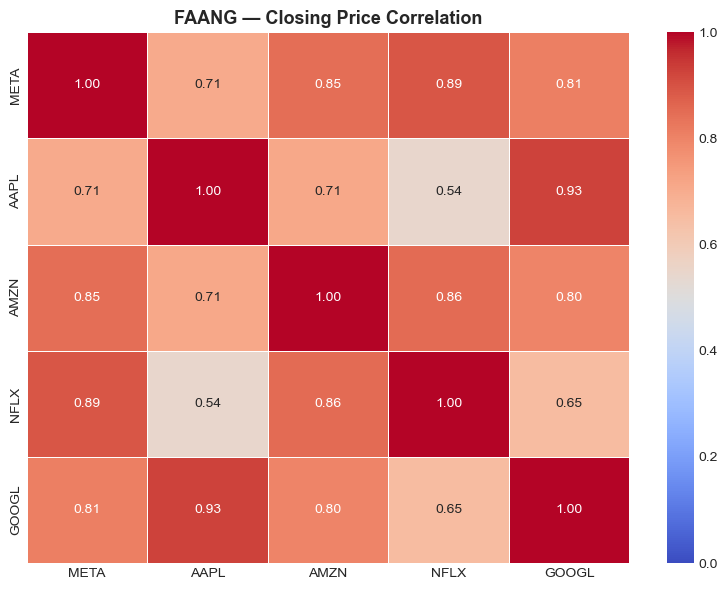

✅ Chart saved


In [5]:
corr = close_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=0, vmax=1,
    ax=ax
)
ax.set_title("FAANG — Closing Price Correlation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/03_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

## Step 6 — Daily Returns

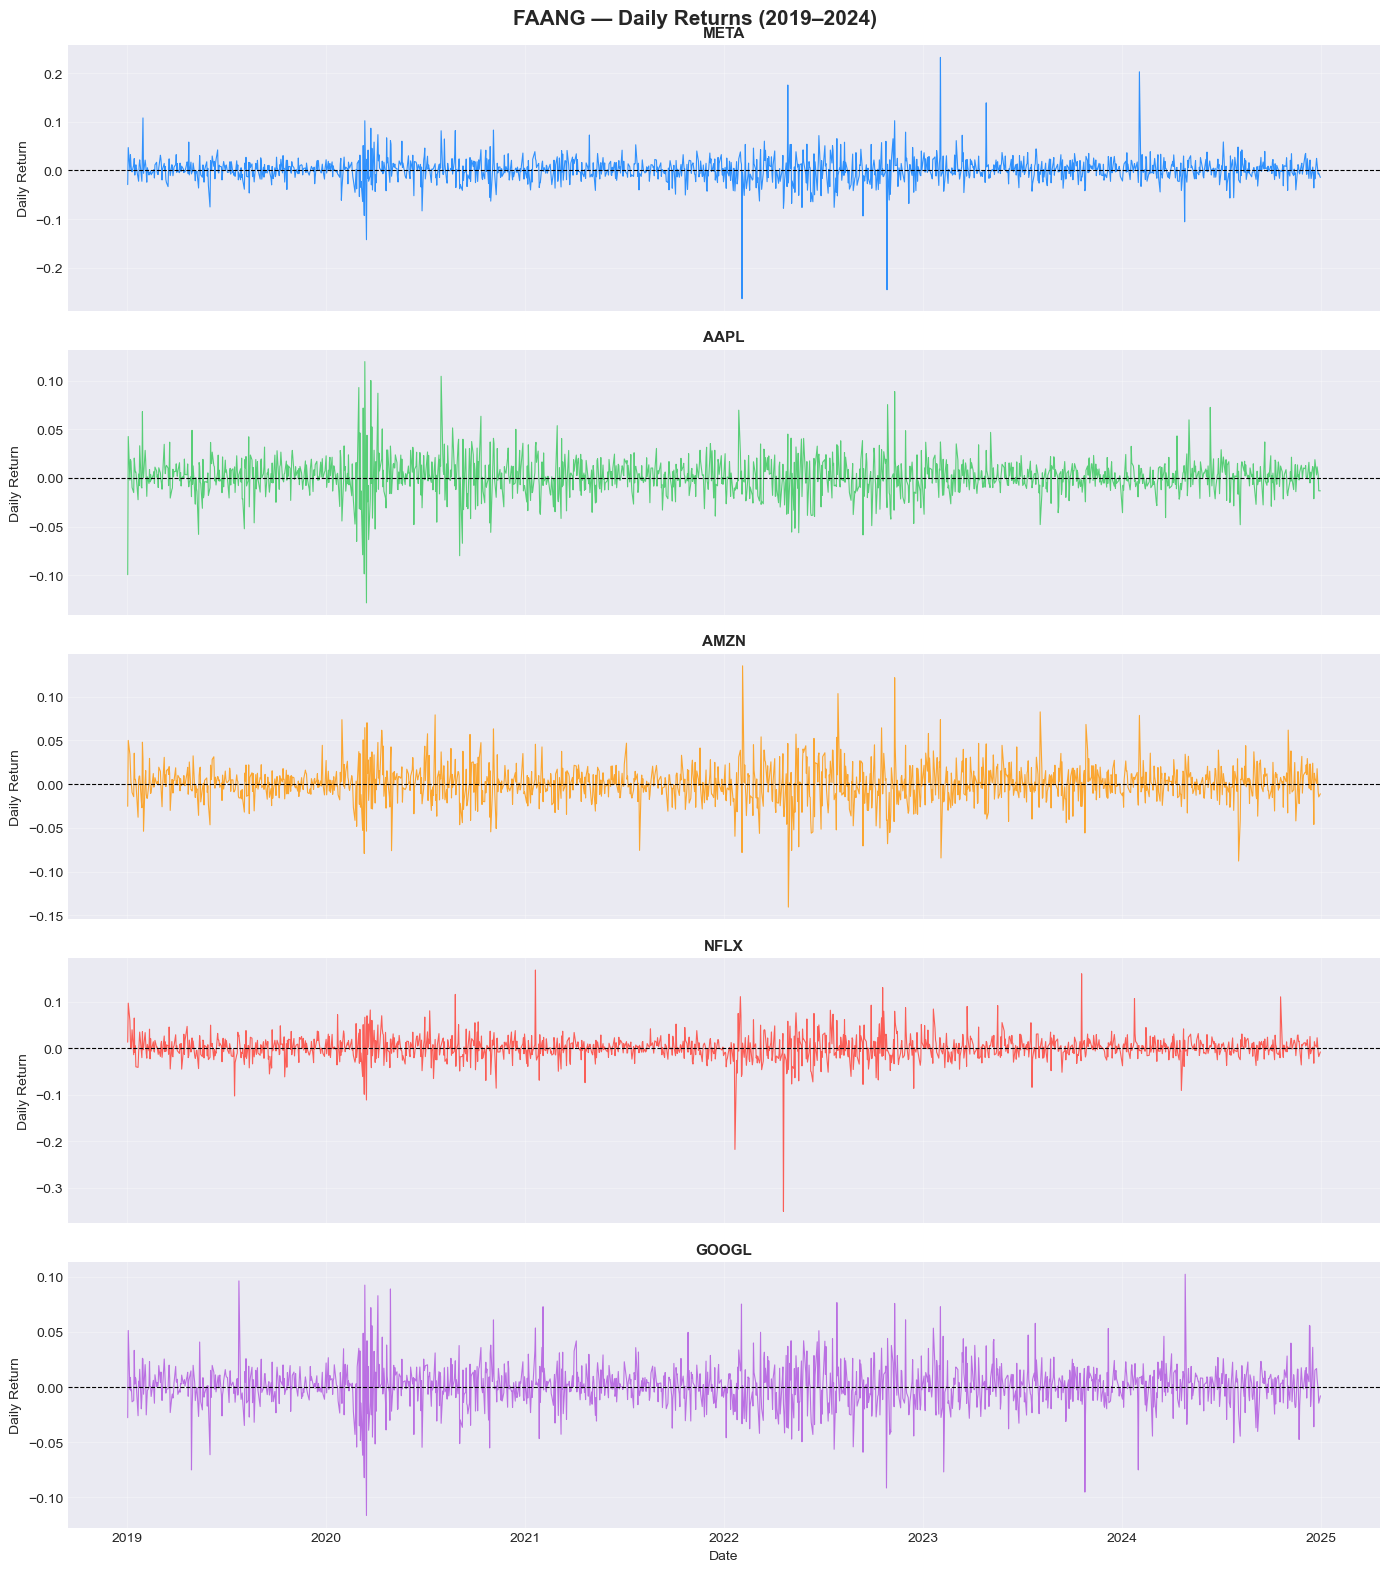

Average Daily Return per Stock:
  META : +0.134%
  AAPL : +0.145%
  AMZN : +0.093%
  NFLX : +0.120%
  GOOGL: +0.105%


In [6]:
returns_df = close_df.pct_change().dropna()

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
fig.suptitle("FAANG — Daily Returns (2019–2024)", fontsize=15, fontweight="bold")

for i, (ticker, color) in enumerate(zip(TICKERS, colors)):
    axes[i].plot(returns_df.index, returns_df[ticker], color=color, linewidth=0.8, alpha=0.8)
    axes[i].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[i].set_title(ticker, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Daily Return")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("data/04_daily_returns.png", dpi=150, bbox_inches="tight")
plt.show()

print("Average Daily Return per Stock:")
for ticker in TICKERS:
    avg = returns_df[ticker].mean() * 100
    print(f"  {ticker:5s}: {avg:+.3f}%")

## Step 7 — Volatility Comparison (Which Stock is Riskiest?)

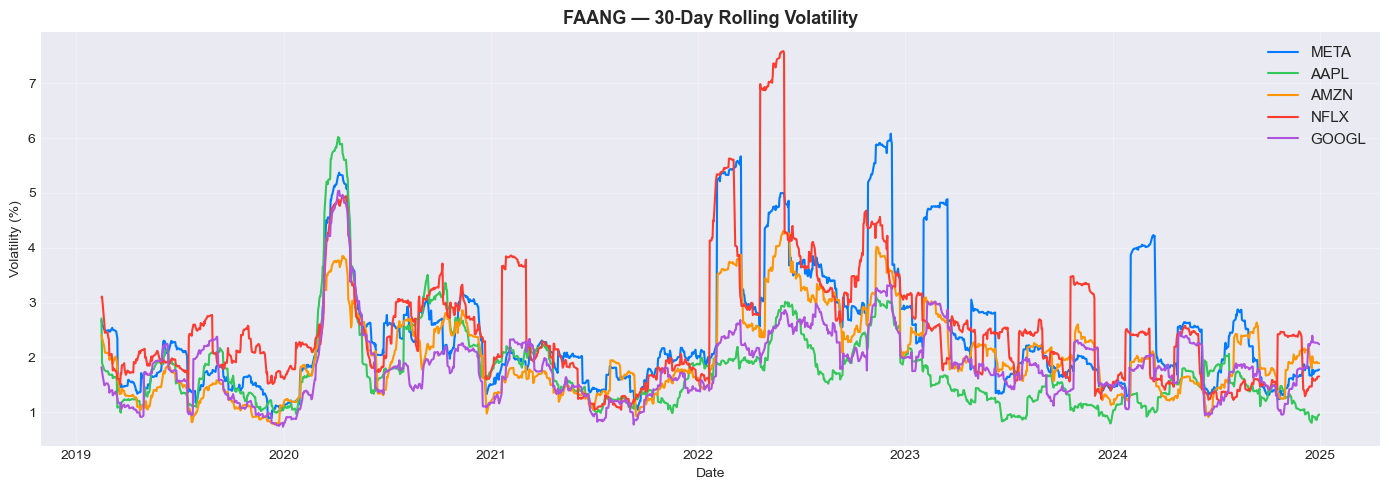

Average Volatility per Stock:
  META : 2.45%
  AAPL : 1.77%
  AMZN : 2.02%
  NFLX : 2.52%
  GOOGL: 1.85%


In [7]:
volatility_df = returns_df.rolling(window=30).std() * 100

fig, ax = plt.subplots(figsize=(14, 5))

for ticker, color in zip(TICKERS, colors):
    ax.plot(volatility_df.index, volatility_df[ticker], label=ticker, color=color, linewidth=1.5)

ax.set_title("FAANG — 30-Day Rolling Volatility", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility (%)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/05_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

print("Average Volatility per Stock:")
for ticker in TICKERS:
    avg_vol = volatility_df[ticker].mean()
    print(f"  {ticker:5s}: {avg_vol:.2f}%")

## ✅ Notebook 2 Summary

**5 Charts created & saved:**
- `01_closing_prices.png` — 5 year price trend for each stock
- `02_normalized_growth.png` — who grew the most from 2019?
- `03_correlation_heatmap.png` — how correlated are these stocks?
- `04_daily_returns.png` — daily up/down movement
- `05_volatility.png` — which stock is riskiest?

**Next →** `03_preprocessing.ipynb`